# Shot Overview Demo

This notebook is a thin example for the reusable `lhd_data.plotting.overview.plot_shot_overview` API. The plotting and signal-selection logic lives in the package; this notebook only chooses a shot, prints a concise cache summary, and renders the overview.


## Configuration

The cache path is explicit so this example uses the existing `local/bh-molecule/` files and never triggers downloads.


In [1]:
from pathlib import Path

from lhd_data.plotting.helpers import DEFAULT_OVERVIEW_DIAGNOSTICS, load_cached_diagnostics, summarize_datasets
from lhd_data.plotting.overview import plot_shot_overview

SHOT = 193788
CACHE_DIR = Path("../local/bh-molecule")
DIAGNOSTICS = DEFAULT_OVERVIEW_DIAGNOSTICS

print(f"Shot: {SHOT}")
print(f"Cache directory: {CACHE_DIR.resolve()}")


Shot: 193788
Cache directory: C:\Users\queezz\Dropbox\20-Code\2026-LHD\local\bh-molecule


## Cached Dataset Summary

Load each cached diagnostic independently and print a compact summary instead of the full `xarray.Dataset` repr.


In [2]:
datasets, failed = load_cached_diagnostics(SHOT, DIAGNOSTICS, cache_dir=CACHE_DIR)
print(summarize_datasets(datasets, failed, diagnostics=DIAGNOSTICS))


nbpwr_tot_temporal  OK  vars=17  time=131072
fircall             OK  vars=15  time=1311
thomson             OK  vars=15  time=360  shape=(Time,R)
ha1                 OK  vars=4  time=12001
ha2                 OK  vars=21  time=1310

thomson:
  Te -> (time, R)
  n_e -> (time, R)


## Overview Plot

By default, density comes from `fircall` and electron temperature comes from `thomson`. Thomson profile data is reduced to a central spatial channel by the package helper.


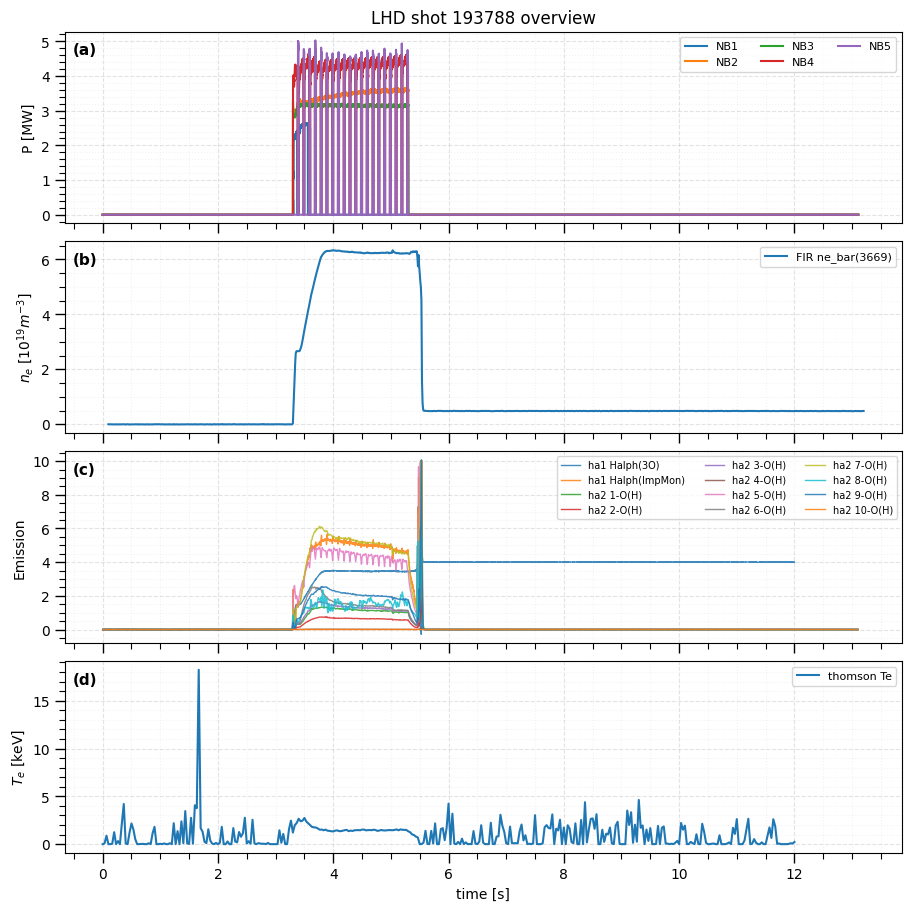

In [5]:
fig = plot_shot_overview(
    shot=SHOT,
    cache_dir=CACHE_DIR,
    datasets=datasets,
)


## Optional Thomson Inspection

Use this quick cell when you want to inspect profile coordinates without dumping every dataset.


In [6]:
thomson = datasets.get("thomson")
if thomson is None:
    print("Thomson data was not loaded.")
else:
    print("coordinates:")
    for name, coord in thomson.coords.items():
        print(f"  {name}: dims={coord.dims}, shape={coord.shape}, units={coord.attrs.get('units', '')}")

    print("\nTe/ne shapes:")
    for name in ("Te", "n_e"):
        if name in thomson:
            print(f"  {name}: dims={thomson[name].dims}, shape={thomson[name].shape}, units={thomson[name].attrs.get('units', '')}")


coordinates:
  Time: dims=('Time',), shape=(360,), units=ms
  R: dims=('R',), shape=(140,), units=mm

Te/ne shapes:
  Te: dims=('Time', 'R'), shape=(360, 140), units=eV
  n_e: dims=('Time', 'R'), shape=(360, 140), units=10^16 m^-3
